In [41]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32) / 255.0
    return img

def GetSobelFeatures(img):
    # Compute x and y gradients using Sobel
    Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Gradient magnitude and orientation
    M = np.sqrt(Gx ** 2 + Gy ** 2)
    Theta = np.arctan2(Gy, Gx)  # in radians

    return Gx, Gy, M, Theta

def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()
    plt.tight_layout()
    plt.show()

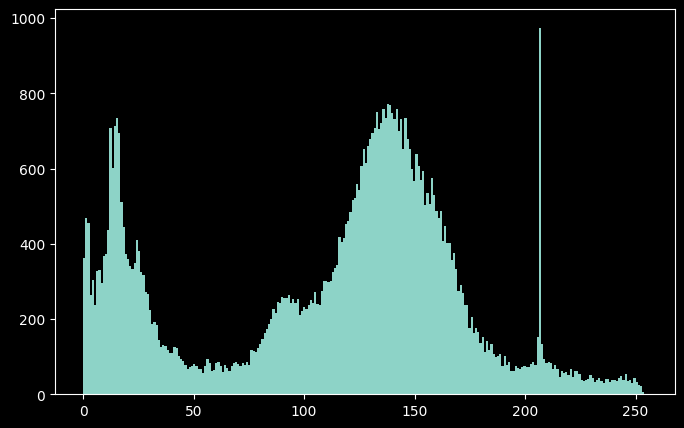

In [42]:
img = LoadImage('dark_object_light_background.jpg')
img = (img*255).astype(np.uint8)
plt.figure(figsize=(8,5))
plt.hist(img.ravel(), bins=256, range=(0,255))
plt.show()


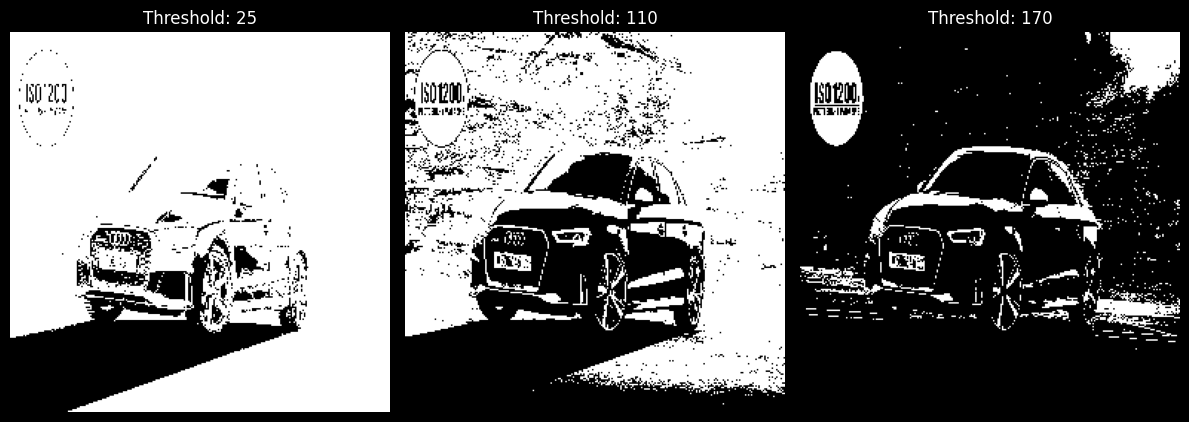

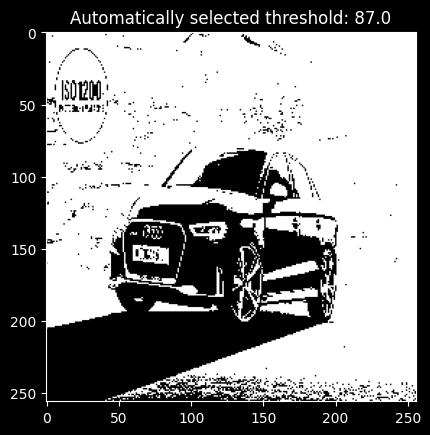

In [43]:
thresholds = [25, 110, 170]

def binary_mask(t, img):
    test = img.copy()
    h,w = img.shape
    for y in range(h):
        for x in range(w):
            pixel = img[y,x]
            test[y,x] = 255 if (pixel > t) else 0
    return test

binary_mask_list = []
t_names = []
for t in thresholds:
    binary_mask_list.append(binary_mask(t, img))
    t_names.append(f"Threshold: {t}")
plot_images_grid(binary_mask_list, t_names, cols=3)

retval, dst = cv2.threshold(img, 0,255, cv2.THRESH_OTSU)

plt.figure()
plt.imshow(dst, cmap='gray')
plt.title(f"Automatically selected threshold: {retval}")
plt.show()


In [44]:
def otsu_intraclass_variance(image, threshold):
    """
    Otsu's intra-class variance.
    If all pixels are above or below the threshold, this will throw a warning that can safely be ignored.
    """
    return np.nansum(
        [
            np.mean(cls) * np.var(image, where=cls)
            #   weight   ·  intra-class variance
            for cls in [image >= threshold, image < threshold]
        ]
    )
    # NaNs only arise if the class is empty, in which case the contribution should be zero, which `nansum` accomplishes.


# Random image for demonstration:
image = LoadImage('dark_object_light_background.jpg')
image = (img).astype(np.uint8)

otsu_threshold = min(
    range(np.min(image) + 1, np.max(image)),
    key=lambda th: otsu_intraclass_variance(image, th),
)
print(otsu_threshold)

88
